# Instance-based vs Model-based Learning
### 1. Introduction
Welcome🧠! in this lecture we will discuss two types of machine learning, which are **instance-based** and **model-based** learning. we will talk about both **Regression** and  **Classification** using the two types of learning, giving the definition, the principle, and practical example of each to illustrate them. I hope you enjoy the lecture. If you find this lecture valuable, please consider sharing it with your mates so they can also benefit. Let's begin!💡

### 2. Definitions
####    2.1 Model-Based Learning
Model-based learning involves creating a mathematical model that can predict outcomes based on input data. The model is trained on a large dataset and then used to make predictions on new data. The model can be thought of as a set of rules that the machine uses to make predictions.
#### 2.2 Instance-Based Learning
Instance-based learning involves using the entire dataset to make predictions. The machine learns by storing all instances of data and then using these instances to make predictions on new data. The machine compares the new data to the instances it has seen before and uses the closest match to make a prediction.

**🔖Source:** [Model-Based vs Instance-Based Learning: Understanding the Differences with Examples - medium](https://medium.com/@pp1222001/model-based-vs-instance-based-learning-understanding-the-differences-with-examples-1545c9c3a056#:~:text=Model-based%20learning%20is%20typically%20faster%20and%20more%20accurate,is%20slower%20and%20can%20make%20less%20accurate%20predictions.)

### 3. Regression
#### 3.1 Instance-based regression
- **Definition:** as we talked previously, in instance-based learning we use the training instances itselves for the prediction. More our instance is similar to a given training instance, more its label value is close to that instance label value.
**i.e** : our_instance ~ given_instance So our_label ~ given_label

- **Principle:** chosing the most similar training instances to the new instance, and use its labels to predict the new label such as the new value will be the average value of the labels values.

- **Example of implementation:** we will implement a regression decision function to predict values using training instances

- Import dataset

In [1]:
import warnings
from sklearn.datasets import make_regression
warnings.filterwarnings('ignore')

data = make_regression(n_features=1, noise=15, bias=20)

- Visualisation of the dataset

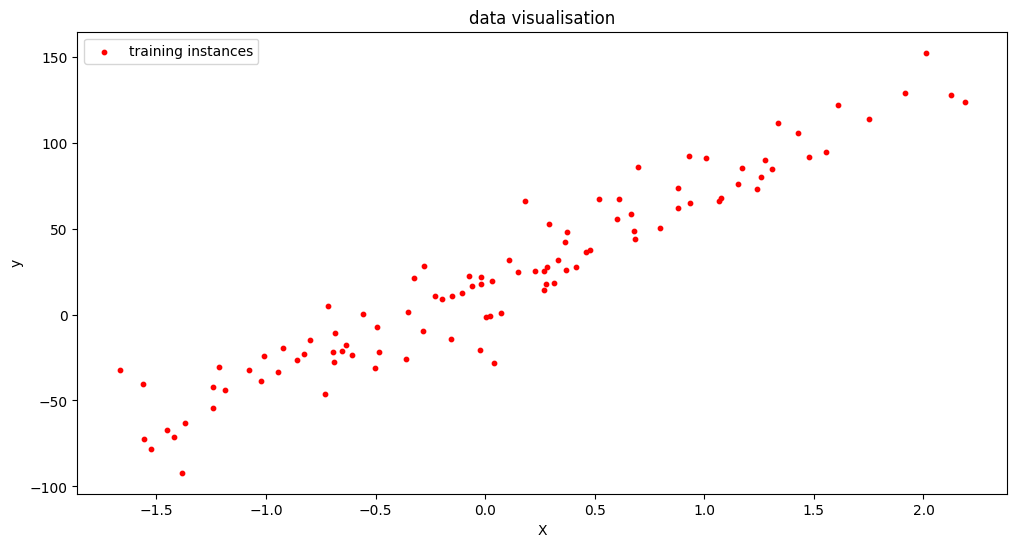

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(111)
ax1.scatter(x=data[0], y=data[1], s=10, c='red', label='training instances')

plt.xlabel('X')
plt.ylabel('y')
plt.legend(loc='best')
plt.title('data visualisation')
fig.show()

- we have to chose the most similar training instances to predict the label of our new instance (those instances called predictors) for that we need a similarity measure. we will chose the simple euclidiean_distance implemented below

In [3]:
from math import sqrt
def euclidean_distance(x,y):
    return np.sqrt(np.sum((np.array(x) - np.array(y)) ** 2))

- instance-based decision function implementation.

I called the parameter alpha "the generalisation rate", is define how the function will generalise the data to predict the new value, by default is 2 (it refer to the number of predictors)

In [4]:
import numpy as np

def decision_function(X, y, new_x, alpha=2):
#       list of all similarties between training instances and new instance
        similarities = [euclidean_distance([x], [new_x]) for x in X]
        
#       predictors are the indexes of the most similar instances to our instance
        predictors = np.argsort(similarities)[:alpha]
    
        prediction = np.mean(y[predictors])
        return prediction, predictors

- new instance prediction

In [5]:
import random as rnd
new_instance = (rnd.random() * 4) - 2       # -2 < new_instance < 2
y_pred, predictors = decision_function(data[0], data[1], new_instance, alpha=5)      # number of predictors = 5
(new_instance, y_pred)

(-0.3288420051133629, 3.1018057337554557)

- visualisation of the new instance and the predictors

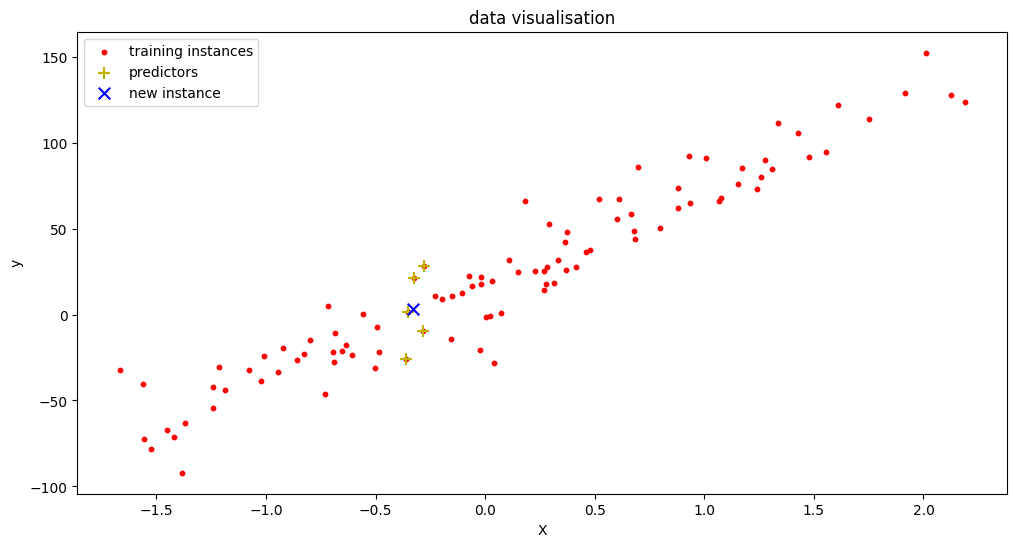

In [6]:
ax1.scatter(data[0][predictors], data[1][predictors], marker='+', c='#BDB300', s=70, label='predictors')
ax1.scatter(x=new_instance, y=y_pred, marker='x', c='blue', s=70, label='new instance')
ax1.legend()
fig

#### 3.2 Model-based regression


- **Definition**: As we talked previousely, in model-base learning we create amodel (or function or formula) that generalise the rules to predict, then use it to make predictions without need of training instances for the prediction

- **Principle**: chose a regression model, fitting it using training instances. then predict new labels using trained model only.

- **Example of implementation**: A simple linear regression is an example of model-based regression

In [7]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(data[0], data[1])

# model parameters (the model: y = w*X + b)
w, b = lr.coef_, lr.intercept_

y_pred = w * new_instance + b

In [8]:
(new_instance, y_pred)

(-0.3288420051133629, array([-0.43066009]))

- visualisation of the model and the new instance

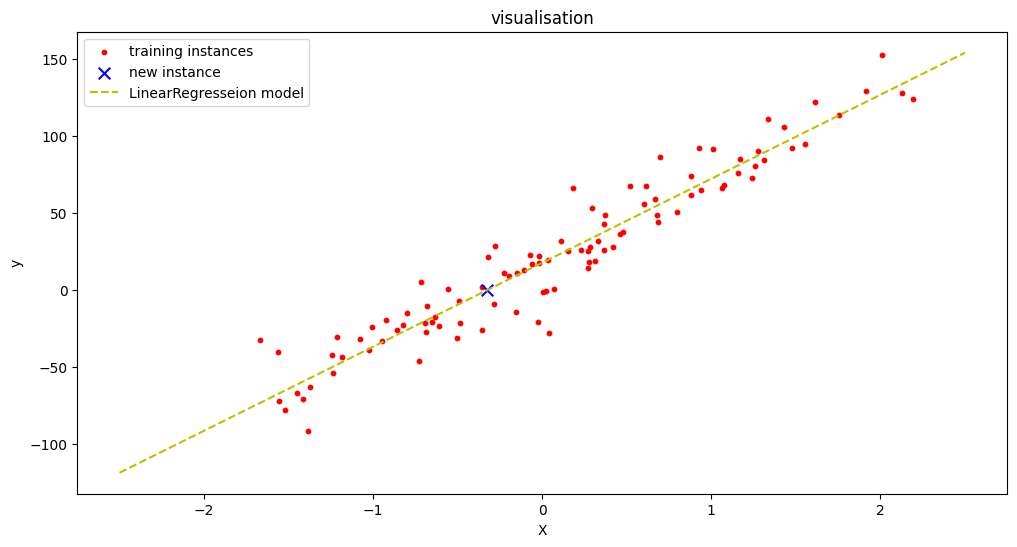

In [9]:
x = np.linspace(-2.5, 2.5, num=100)
y = w*x + b


fig2 = plt.figure(figsize=(12, 6))
ax2 = fig2.add_subplot(111)

ax2.scatter(x=data[0], y=data[1], s=10, c='red', label='training instances')
ax2.scatter(x=new_instance, y=y_pred, marker='x', c='blue', s=70, label='new instance')
ax2.plot(x, y, 'y--', label='LinearRegresseion model')

plt.xlabel('X')
plt.ylabel('y')
plt.legend(loc='best')
plt.title('visualisation')
fig2.show()

### 4. Classification
#### 4.1 Instance-based Classification
- **Definition:** we defined it previously (see section 3.1)

- **Principle:** we chose a number **n** of the most similar instances to the new instance (the number n is refered by the parameter alpha), then the class of the new instance is the majority class in those instances set (the most occured class)

- **Example of implementation:** implement a classifier using the training instances directly without training

- Import dataset 

In [10]:
from sklearn.datasets import make_moons
data = make_moons(noise=0.3)
X = data[0]
y = data [1]

- Visualisation of the dataset

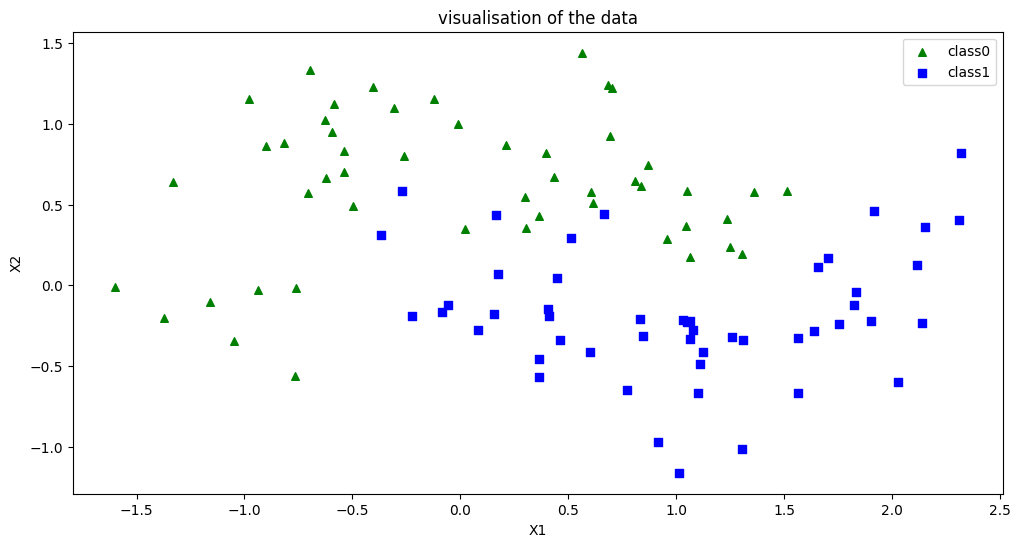

In [11]:
fig3 = plt.figure(figsize=(12, 6))
ax3 = fig3.add_subplot(111)

ax3.scatter(X[y==0][:, 0], X[y==0][:, 1], marker='^', s=30, c='green', label='class0')
ax3.scatter(X[y==1][:, 0], X[y==1][:, 1], marker='s', s=30, c='blue', label='class1')

plt.title('visualisation of the data')
plt.legend()
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

- Decision function implementation

We will use the same similarity measure as before wich is ***euclidian distance()***. we will also use ***mode()*** function to select the majority class

In [12]:
import statistics

def instance_based_classifier(X, y, new_x, alpha): 
    similarities = [euclidean_distance(x, new_x) for x in X]
    predictors = np.argsort(similarities)[:alpha]
    prediction = statistics.mode(y[predictors])
    return prediction, predictors

- New instance

In [13]:
new_instance = np.array([1.25, 0.25])
y_pred, predictors = instance_based_classifier(X, y, new_instance, alpha=20)
(new_instance, y_pred)

(array([1.25, 0.25]), 0)

- visualisation of the new instance and the predictors

Text(0, 0.5, 'X2')

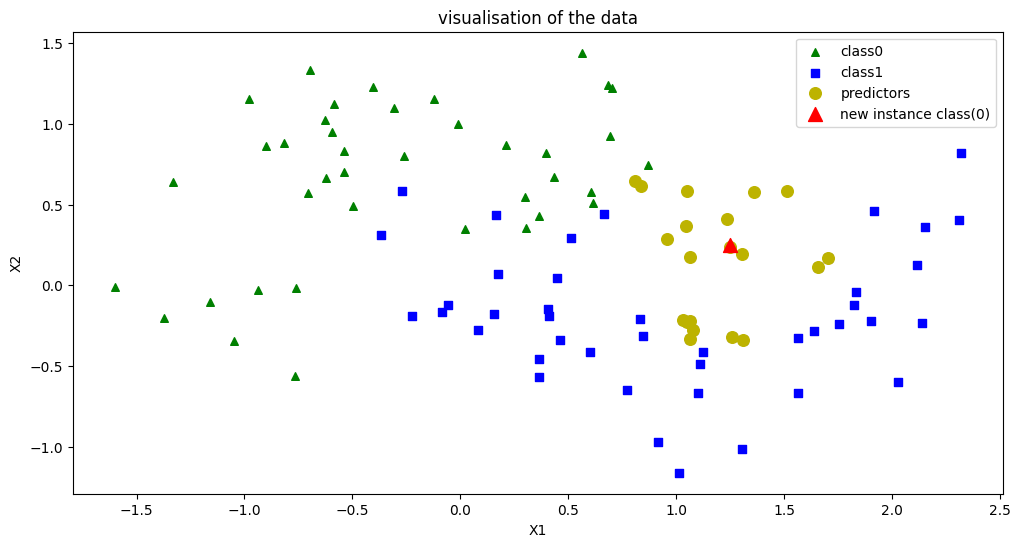

In [14]:
fig4 = plt.figure(figsize=(12, 6))
ax4 = fig4.add_subplot(111)

ax4.scatter(X[y==0][:, 0], X[y==0][:, 1], marker='^', s=30, c='green', label='class0')
ax4.scatter(X[y==1][:, 0], X[y==1][:, 1], marker='s', s=30, c='blue', label='class1')
ax4.scatter(X[predictors][:, 0], X[predictors][:, 1], marker='o', c='#BDB300', s=70, label='predictors')

class_shape = {
    0: '^',
    1: 's'
}

marker = class_shape[y_pred]
ax4.scatter(new_instance[0], new_instance[1], marker=marker, c='red', s=100, label=f'new instance class({y_pred})')

plt.title('visualisation of the data')
plt.legend()
plt.xlabel('X1')
plt.ylabel('X2')

#### 4.2 Model-based Classification
- **Definition:** we defined it previously (see section 3.2)

- **Principle:** chose a classification model, fitting it using training instances. then predict new class using trained model only.

- **Example of implementation:** Decision Tree classifier is an example of model-based classification

- import, fit, and visualise the model

[Text(0.5, 0.75, 'x[1] <= 0.172\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.25, 'gini = 0.249\nsamples = 48\nvalue = [7, 41]'),
 Text(0.75, 0.25, 'gini = 0.286\nsamples = 52\nvalue = [43, 9]')]

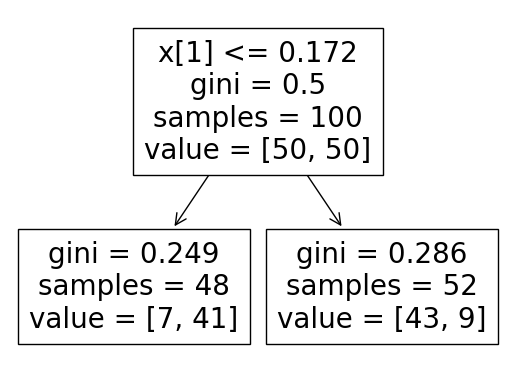

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dtc = DecisionTreeClassifier(max_depth=1)
dtc.fit(X, y)

plot_tree(dtc)

- new instance prediction

In [16]:
new_instance = np.array([1, -0.125])

y_pred = dtc.predict([new_instance])
(new_instance, y_pred[0])

(array([ 1.   , -0.125]), 1)

- visualisation of the data

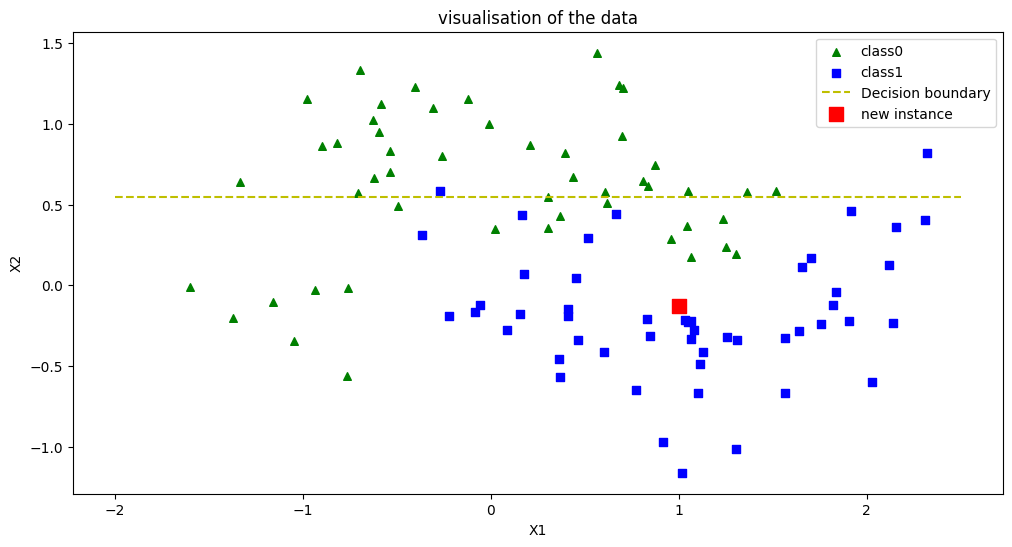

In [17]:
fig5 = plt.figure(figsize=(12, 6))
ax5 = fig5.add_subplot(111)

ax5.scatter(X[y==0][:, 0], X[y==0][:, 1], marker='^', s=30, c='green', label='class0')
ax5.scatter(X[y==1][:, 0], X[y==1][:, 1], marker='s', s=30, c='blue', label='class1')

x = np.linspace(-2, 2.5, 100)
ax5.plot(x, np.full(100, 0.545), 'y--', label='Decision boundary')

class_shape = {
    0: '^',
    1: 's'
}
ax5.scatter(new_instance[0], new_instance[1], c='red', marker=class_shape[y_pred[0]], s=100, label='new instance')


plt.title('visualisation of the data')
plt.legend()
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

# That's it
That was the difference between the two techniques of machine learning. if you find this lecture usefull, share it with your mates 😊